# E3-Substrate Interaction Network Analysis and Pathway Enrichment Tutorial

This notebook is used to reproduce the main figures for Figure 4.

This notebook performs comprehensive network analysis on E3 ligase-substrate interaction data predicted by Ubicon, including pathway enrichment analysis.

## Required Library Installation

```bash
# Required for Louvain community detection
pip install python-louvain

# Required for pathway enrichment analysis
pip install gprofiler-official
```

In [43]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from community import best_partition  # python-louvain package
import numpy as np
from gprofiler import GProfiler  # For pathway enrichment analysis

print("Libraries imported successfully")

Libraries imported successfully


## 1. Loading Network Data and Constructing Graphs

Load the prediction results CSV file and construct a NetworkX graph.
By including only edges with calibrated_score above a certain threshold, we focus on high-confidence interactions.

**Note: Please prepare `sakuma_table_s5.csv` in this directory before running the analysis.**

In [ ]:
# Specify data file paths
# Note: Modify these paths according to your actual file locations
data_file = 'sakuma_table_s5.csv'  # CSV with columns: e3_uniprot_id, substrate_uniprot_id, calibrated_score
nodes_file = 'cytoscape_nodes.csv'  # CSV with columns: id, type (E3 or substrate)

# Load data
df = pd.read_csv(data_file)
nodes = pd.read_csv(nodes_file)

print(f"Loaded data: {len(df)} rows")
print(f"\nData sample:")
print(df.head())

Loaded data: 5898392 rows

Data sample:
  e3_uniprot_id substrate_uniprot_id  Ubicon score
0        Q96BH1               P23921      0.206704
1        Q96BH1               P23945      0.686391
2        Q96BH1               P24001      0.016915
3        Q96BH1               P24046      0.123123
4        Q96BH1               P24071      0.725806


In [45]:
# Filter by threshold
threshold = 0.80  # Threshold for Ubicon_score (adjust as needed)
filtered_df = df[df['Ubicon score'] >= threshold]
print(f"Number of edges with score >= {threshold}: {len(filtered_df)}")

# Construct NetworkX graph
G = nx.from_pandas_edgelist(
    filtered_df,
    source='e3_uniprot_id',
    target='substrate_uniprot_id',
    edge_attr=['Ubicon score']
)

print(f"\nGraph basic information:")
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")

Number of edges with score >= 0.8: 207816

Graph basic information:
Number of nodes: 15964
Number of edges: 206348


In [46]:
# Add node type (E3 ligase or substrate) as an attribute
e3_ligases = nodes[nodes['type'] == 'E3']['id'].tolist()

for node in G.nodes():
    if node in e3_ligases:
        G.nodes[node]['type'] = 'E3'
    else:
        G.nodes[node]['type'] = 'substrate'

print(f"Number of E3 ligases: {len(e3_ligases)}")
print(f"Number of substrates: {G.number_of_nodes() - len([n for n in G.nodes() if G.nodes[n].get('type') == 'E3'])}")

Number of E3 ligases: 470
Number of substrates: 15495


## 2. Degree Analysis (Hub Identification)

Calculate the degree (number of connections) for each node and identify hub E3 ligases and hub substrates with many interactions.

In [47]:
# Calculate degrees
degrees = dict(G.degree())

# Separate degrees for E3 ligases and substrates
e3_degrees = {node: degree for node, degree in degrees.items()
              if G.nodes[node]['type'] == 'E3'}
substrate_degrees = {node: degree for node, degree in degrees.items()
                    if G.nodes[node]['type'] == 'substrate'}

# Sort by degree in descending order
sorted_e3_degrees = dict(sorted(e3_degrees.items(), key=lambda x: x[1], reverse=True))
sorted_substrate_degrees = dict(sorted(substrate_degrees.items(), key=lambda x: x[1], reverse=True))

# Extract top 10
top10_e3 = dict(list(sorted_e3_degrees.items())[:10])
top10_substrates = dict(list(sorted_substrate_degrees.items())[:10])

print("Top 10 E3 ligases (by degree):")
for e3, degree in top10_e3.items():
    print(f"{e3}: {degree} interactions")

print("\nTop 10 substrates (by degree):")
for substrate, degree in top10_substrates.items():
    print(f"{substrate}: {degree} interactions")

Top 10 E3 ligases (by degree):
O43791: 14358 interactions
Q12933: 8148 interactions
Q13114: 7875 interactions
P35226: 6837 interactions
P78317: 4989 interactions
Q13233: 4643 interactions
O95628: 4407 interactions
Q7Z6M2: 4331 interactions
O15524: 4089 interactions
P29590: 3836 interactions

Top 10 substrates (by degree):
Q13887: 303 interactions
O43474: 294 interactions
Q15583: 259 interactions
Q99750: 256 interactions
P54829: 255 interactions
P42226: 247 interactions
Q5TA89: 246 interactions
P41134: 239 interactions
O75496: 238 interactions
P15173: 238 interactions


In [48]:
# Calculate average degrees
avg_e3_degree = sum(e3_degrees.values()) / len(e3_degrees) if e3_degrees else 0
avg_substrate_degree = sum(substrate_degrees.values()) / len(substrate_degrees) if substrate_degrees else 0

print(f"Average degree of E3 ligases: {avg_e3_degree:.2f}")
print(f"Average degree of substrates: {avg_substrate_degree:.2f}")

Average degree of E3 ligases: 456.70
Average degree of substrates: 12.81


Top 10 E3 ligases (by degree):
O43791: 14358 interactions
Q12933: 8148 interactions
Q13114: 7875 interactions
P35226: 6837 interactions
P78317: 4989 interactions
Q13233: 4643 interactions
O95628: 4407 interactions
Q7Z6M2: 4331 interactions
O15524: 4089 interactions
P29590: 3836 interactions

Top 10 substrates (by degree):
Q13887: 303 interactions
O43474: 294 interactions
Q15583: 259 interactions
Q99750: 256 interactions
P54829: 255 interactions
P42226: 247 interactions
Q5TA89: 246 interactions
P41134: 239 interactions
O75496: 238 interactions
P15173: 238 interactions

Average degree of E3 ligases: 456.70
Average degree of substrates: 12.81
Overall average degree: 25.85

Average clustering coefficient (E3 ligases): 0.2556
Average clustering coefficient (substrates): 0.5961
Overall average clustering coefficient: 0.5861


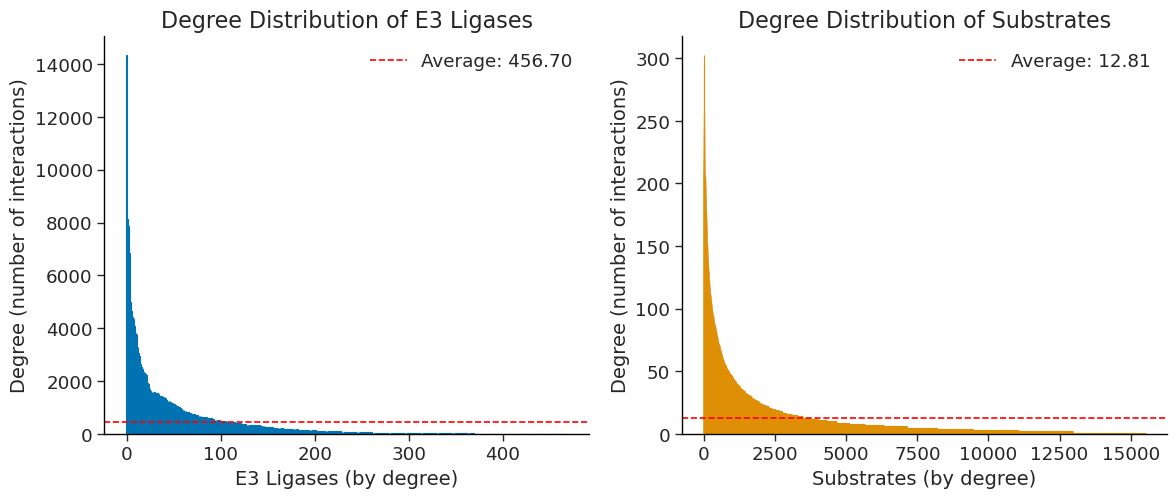

In [49]:
# Matplotlib and style settings
%matplotlib inline
import matplotlib.pyplot as plt

# Style settings
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0
plt.rcParams['xtick.direction'] = 'out'
plt.rcParams['ytick.direction'] = 'out'

# Theme and context
sns.set_style("ticks")
sns.set_context("paper", font_scale=1.5)

# Color palette
palette = sns.color_palette("colorblind")

# Display results
print("Top 10 E3 ligases (by degree):")
for e3, degree in top10_e3.items():
	print(f"{e3}: {degree} interactions")

print("\nTop 10 substrates (by degree):")
for substrate, degree in top10_substrates.items():
	print(f"{substrate}: {degree} interactions")

# Calculate average degrees
avg_e3_degree = sum(e3_degrees.values()) / len(e3_degrees) if e3_degrees else 0
avg_substrate_degree = sum(substrate_degrees.values()) / len(substrate_degrees) if substrate_degrees else 0
avg_total_degree = sum(degrees.values()) / len(degrees) if degrees else 0

# Calculate clustering coefficients
clustering_coefficients = nx.clustering(G)
e3_clustering_full = {node: coef for node, coef in clustering_coefficients.items()
					  if G.nodes[node]['type'] == 'E3'}
substrate_clustering_full = {node: coef for node, coef in clustering_coefficients.items()
							 if G.nodes[node]['type'] == 'substrate'}

# Average clustering coefficients
avg_e3_clustering = sum(e3_clustering_full.values()) / len(e3_clustering_full) if e3_clustering_full else 0
avg_substrate_clustering = sum(substrate_clustering_full.values()) / len(substrate_clustering_full) if substrate_clustering_full else 0
avg_total_clustering = sum(clustering_coefficients.values()) / len(clustering_coefficients) if clustering_coefficients else 0

print(f"\nAverage degree of E3 ligases: {avg_e3_degree:.2f}")
print(f"Average degree of substrates: {avg_substrate_degree:.2f}")
print(f"Overall average degree: {avg_total_degree:.2f}")

print(f"\nAverage clustering coefficient (E3 ligases): {avg_e3_clustering:.4f}")
print(f"Average clustering coefficient (substrates): {avg_substrate_clustering:.4f}")
print(f"Overall average clustering coefficient: {avg_total_clustering:.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Degree distribution of E3 ligases
ax = axes[0]
ax.bar(range(len(sorted_e3_degrees)), list(sorted_e3_degrees.values()), color=palette[0], edgecolor=palette[0])
ax.axhline(y=avg_e3_degree, color='red', linestyle='--', label=f'Average: {avg_e3_degree:.2f}')
ax.set_xlabel('E3 Ligases (by degree)', fontsize=14)
ax.set_ylabel('Degree (number of interactions)', fontsize=14)
ax.set_title('Degree Distribution of E3 Ligases', fontsize=16)
ax.legend(frameon=False, loc='best')

# Border settings
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
for spine_name, spine in ax.spines.items():
	if spine_name in ['left', 'bottom']:
		spine.set_edgecolor('black')
		spine.set_linewidth(1)

# Remove grid
ax.grid(False)

# Degree distribution of substrates
ax = axes[1]
ax.bar(range(len(sorted_substrate_degrees)), list(sorted_substrate_degrees.values()), color=palette[1], edgecolor=palette[1])
ax.axhline(y=avg_substrate_degree, color='red', linestyle='--', label=f'Average: {avg_substrate_degree:.2f}')
ax.set_xlabel('Substrates (by degree)', fontsize=14)
ax.set_ylabel('Degree (number of interactions)', fontsize=14)
ax.set_title('Degree Distribution of Substrates', fontsize=16)
ax.legend(frameon=False, loc='best')

# Border settings
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
for spine_name, spine in ax.spines.items():
	if spine_name in ['left', 'bottom']:
		spine.set_edgecolor('black')
		spine.set_linewidth(1)

# Remove grid
ax.grid(False)

# Adjust margins
plt.tight_layout(rect=[0, 0.05, 1, 0.92])

# Save figures
plt.savefig('degree_distribution.svg', format='svg', bbox_inches='tight', dpi=300)
plt.savefig('degree_distribution.png', format='png', bbox_inches='tight', dpi=300)

plt.show()

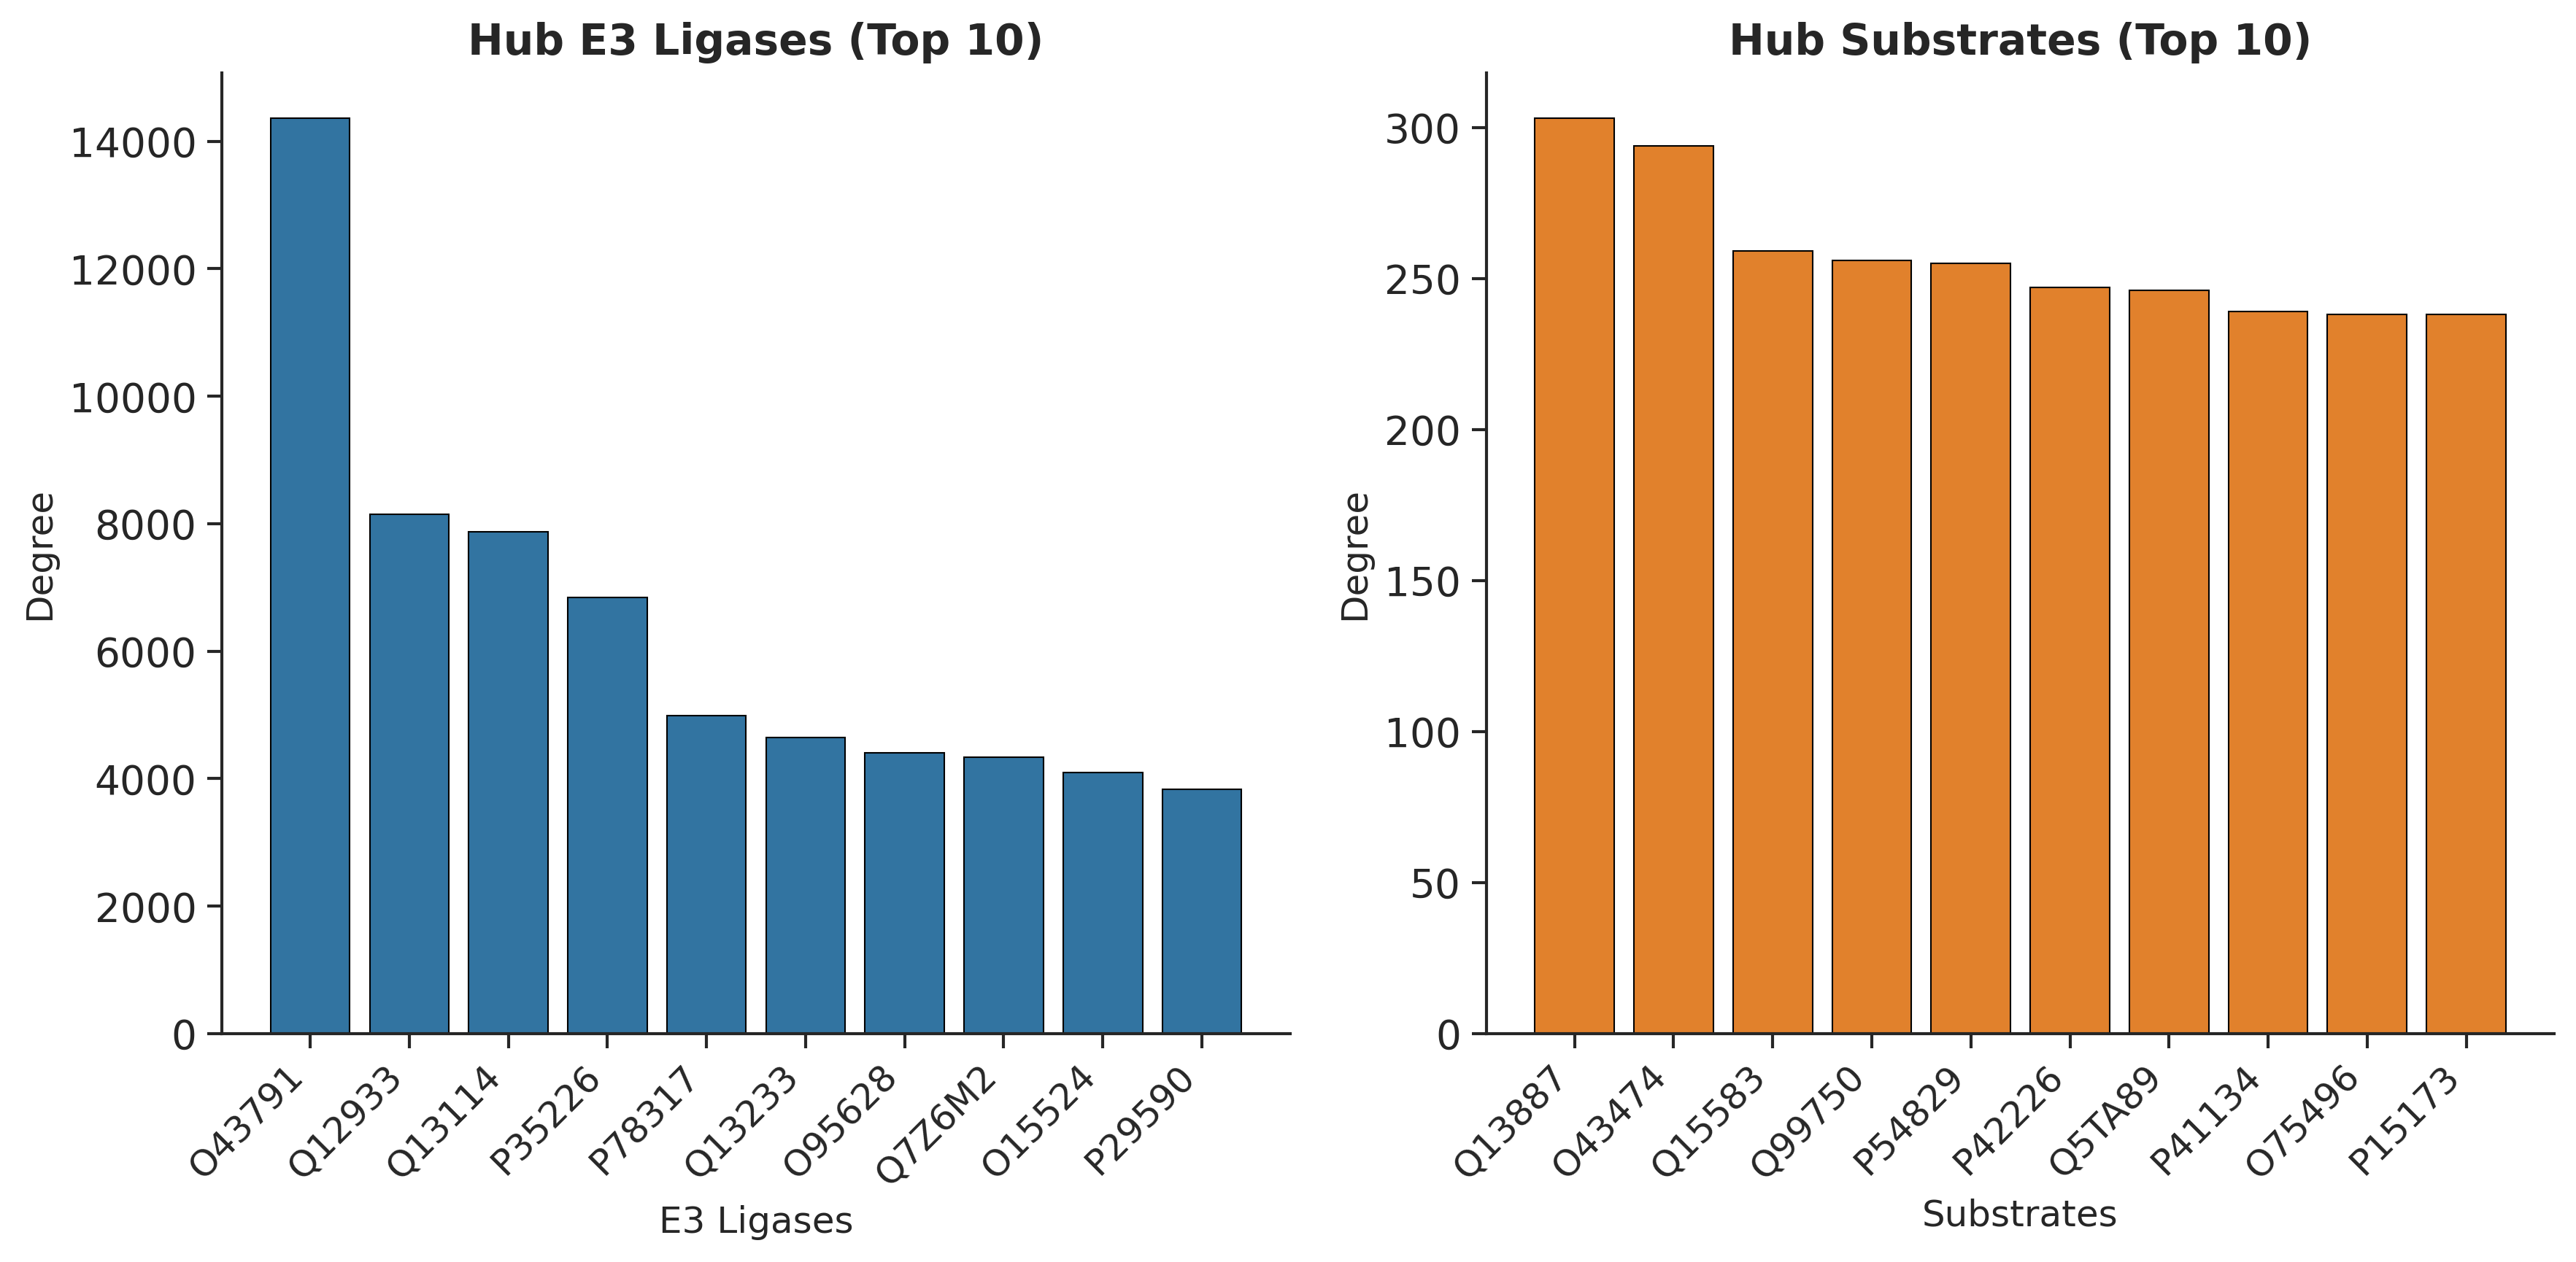

In [50]:
# Visualize top 10 hub E3 ligases and hub substrates
top10_e3_items = list(sorted_e3_degrees.items())[:10]
top10_substrate_items = list(sorted_substrate_degrees.items())[:10]

plt.figure(figsize=(12, 6), dpi=300)

# Hub E3 Ligases (Top 10)
plt.subplot(1, 2, 1)
e3_ids = [e3 for e3, _ in top10_e3_items]
e3_degrees_values = [degree for _, degree in top10_e3_items]
plt.bar(range(len(e3_ids)), e3_degrees_values, color='#3274A1', edgecolor='black', linewidth=0.5)
plt.xticks(range(len(e3_ids)), e3_ids, rotation=45, ha='right', fontsize=12)
plt.title('Hub E3 Ligases (Top 10)', fontsize=14, fontweight='bold')
plt.xlabel('E3 Ligases', fontsize=12)
plt.ylabel('Degree', fontsize=12)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)

# Hub Substrates (Top 10)
plt.subplot(1, 2, 2)
substrate_ids = [substrate for substrate, _ in top10_substrate_items]
substrate_degrees_values = [degree for _, degree in top10_substrate_items]
plt.bar(range(len(substrate_ids)), substrate_degrees_values, color='#E1812C', edgecolor='black', linewidth=0.5)
plt.xticks(range(len(substrate_ids)), substrate_ids, rotation=45, ha='right', fontsize=12)
plt.title('Hub Substrates (Top 10)', fontsize=14, fontweight='bold')
plt.xlabel('Substrates', fontsize=12)
plt.ylabel('Degree', fontsize=12)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig('hub_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Community Detection (Louvain Method)

Detect communities (densely connected node groups) within the network using the Louvain method.

In [56]:
import random

# Community detection using Louvain method
partition = best_partition(G, random_state=938)

# Add results as node attributes
for node, community_id in partition.items():
    G.nodes[node]['community'] = community_id

# Number of communities
num_communities = len(set(partition.values()))
print(f"Number of detected communities: {num_communities}")

Number of detected communities: 3


In [57]:
# Calculate number of nodes per community
community_sizes = {}
for node, community_id in partition.items():
    if community_id not in community_sizes:
        community_sizes[community_id] = 0
    community_sizes[community_id] += 1

# Sort by community size
sorted_communities = sorted(community_sizes.items(), key=lambda x: x[1], reverse=True)

# Display top 10 communities
print("Top 10 communities and their sizes:")
for i, (comm_id, size) in enumerate(sorted_communities[:10]):
    print(f"Community {comm_id}: {size} nodes")

Top 10 communities and their sizes:
Community 1: 11090 nodes
Community 2: 3118 nodes
Community 0: 1756 nodes


In [58]:
# Calculate number of E3 ligases and substrates per community
e3_list = nodes[nodes['type'] == 'E3']['id'].tolist()
substrate_list = df['substrate_uniprot_id'].unique()

community_e3s = {}
community_substrates = {}

for node, community_id in partition.items():
    if community_id not in community_e3s:
        community_e3s[community_id] = 0
        community_substrates[community_id] = 0

    if node in e3_list:
        community_e3s[community_id] += 1
    if node in substrate_list:
        community_substrates[community_id] += 1

In [59]:
# Display E3 ligases and substrates in the largest community
largest_community_id = sorted_communities[0][0]
largest_community_nodes = [node for node, comm_id in partition.items() if comm_id == largest_community_id]

largest_community_e3s = [node for node in largest_community_nodes if node in e3_list]
largest_community_substrates = [node for node in largest_community_nodes if node in substrate_list]

print(f"Composition of largest community (ID: {largest_community_id}):")
print(f"Number of E3 ligases: {len(largest_community_e3s)}")
print(f"Number of substrates: {len(largest_community_substrates)}")

print("\nE3 ligase examples from largest community (first 5):")
for e3 in largest_community_e3s[:5]:
    print(f"- {e3}")

print("\nSubstrate examples from largest community (first 5):")
for substrate in largest_community_substrates[:5]:
    print(f"- {substrate}")

Composition of largest community (ID: 1):
Number of E3 ligases: 94
Number of substrates: 11089

E3 ligase examples from largest community (first 5):
- Q13501
- Q7Z6M2
- Q9HCE7
- P35226
- P78317

Substrate examples from largest community (first 5):
- C9JDP6
- Q13501
- Q7Z6M2
- Q9HCE7
- Q9Y239


## 4. Clustering Coefficient Calculation

The clustering coefficient indicates how densely connected a node's neighborhood is.

In [60]:
# Clustering coefficient for entire network
clustering_coefficient = nx.average_clustering(G)
print(f"Average clustering coefficient: {clustering_coefficient:.4f}")

# Clustering coefficient for all E3 ligases
all_e3_clustering = nx.clustering(G, e3_list)
avg_e3_clustering = sum(all_e3_clustering.values()) / len(all_e3_clustering) if all_e3_clustering else 0
print(f"Average clustering coefficient of E3 ligases: {avg_e3_clustering:.4f}")

# Clustering coefficient for largest community
e3_clustering = nx.clustering(G, largest_community_e3s)
substrate_clustering = nx.clustering(G, largest_community_substrates)

avg_comm_e3_clustering = sum(e3_clustering.values()) / len(e3_clustering) if e3_clustering else 0
avg_comm_substrate_clustering = sum(substrate_clustering.values()) / len(substrate_clustering) if substrate_clustering else 0

print(f"Average clustering coefficient of E3 ligases in largest community: {avg_comm_e3_clustering:.4f}")
print(f"Average clustering coefficient of substrates in largest community: {avg_comm_substrate_clustering:.4f}")

Average clustering coefficient: 0.5861
Average clustering coefficient of E3 ligases: 0.2556
Average clustering coefficient of E3 ligases in largest community: 0.5949
Average clustering coefficient of substrates in largest community: 0.6702


## 5. KEGG Pathway Enrichment Analysis using g:Profiler

Perform KEGG pathway enrichment analysis for each community to identify over-represented biological pathways.

### 5.1 KEGG Pathway Enrichment Analysis for Top 3 Communities

In [61]:
# Analyze top 3 communities for KEGG pathway enrichment
target_communities = [comm_id for comm_id, _ in sorted_communities[:3]]

# Dictionary to store results
kegg_results = {}

print("\nKEGG pathway-specific enrichment analysis:")
print("="*60)

for community_id in target_communities:
    print(f"\nCommunity {community_id} - KEGG pathways:")

    # Extract nodes belonging to this community
    community_nodes = [node for node, comm_id in partition.items() if comm_id == community_id]

    # Create substrate-only list (exclude E3 ligases)
    substrate_only = [node for node in community_nodes if node not in e3_list]
    gene_list = substrate_only

    if len(gene_list) > 0:
        gp = GProfiler(return_dataframe=True)

        try:
            # Perform KEGG-only enrichment analysis
            results = gp.profile(
                organism='hsapiens',
                query=gene_list,
                sources=['KEGG'],
            )

            if not results.empty:
                print(f"\nTop 10 KEGG pathways:")
                display_cols = ['name', 'p_value', 'term_size', 'query_size', 'intersection_size', 'source']
                print(results[display_cols].head(10).to_string())

                # Store results in memory (no file saving)
                kegg_results[community_id] = results

                # Uncomment the following lines to save results to CSV file if needed
                # output_file = f"community_{community_id}_KEGG_enrichment.csv"
                # results.to_csv(output_file, index=False)
                # print(f"\nSaved KEGG enrichment results to {output_file}")
            else:
                print("No significant KEGG pathway enrichment found")
        except Exception as e:
            print(f"Error during KEGG enrichment analysis: {e}")
    else:
        print("No substrates to analyze")

print("\nAnalysis results are stored in kegg_results dictionary")
print(f"Available communities: {list(kegg_results.keys())}")


KEGG pathway-specific enrichment analysis:

Community 1 - KEGG pathways:

Top 10 KEGG pathways:
                                          name       p_value  term_size  query_size  intersection_size source
0                           Metabolic pathways  9.460962e-07       1537        4095                843   KEGG
1                  Nucleocytoplasmic transport  1.506048e-06        108        4095                 81   KEGG
2    SNARE interactions in vesicular transport  6.675808e-05         32        4095                 29   KEGG
3                                   Proteasome  2.033799e-04         46        4095                 38   KEGG
4                  Basal transcription factors  2.055939e-04         43        4095                 36   KEGG
5                    mRNA surveillance pathway  2.773913e-04         96        4095                 69   KEGG
6                              RNA degradation  1.774255e-03         79        4095                 57   KEGG
7  Protein processing i

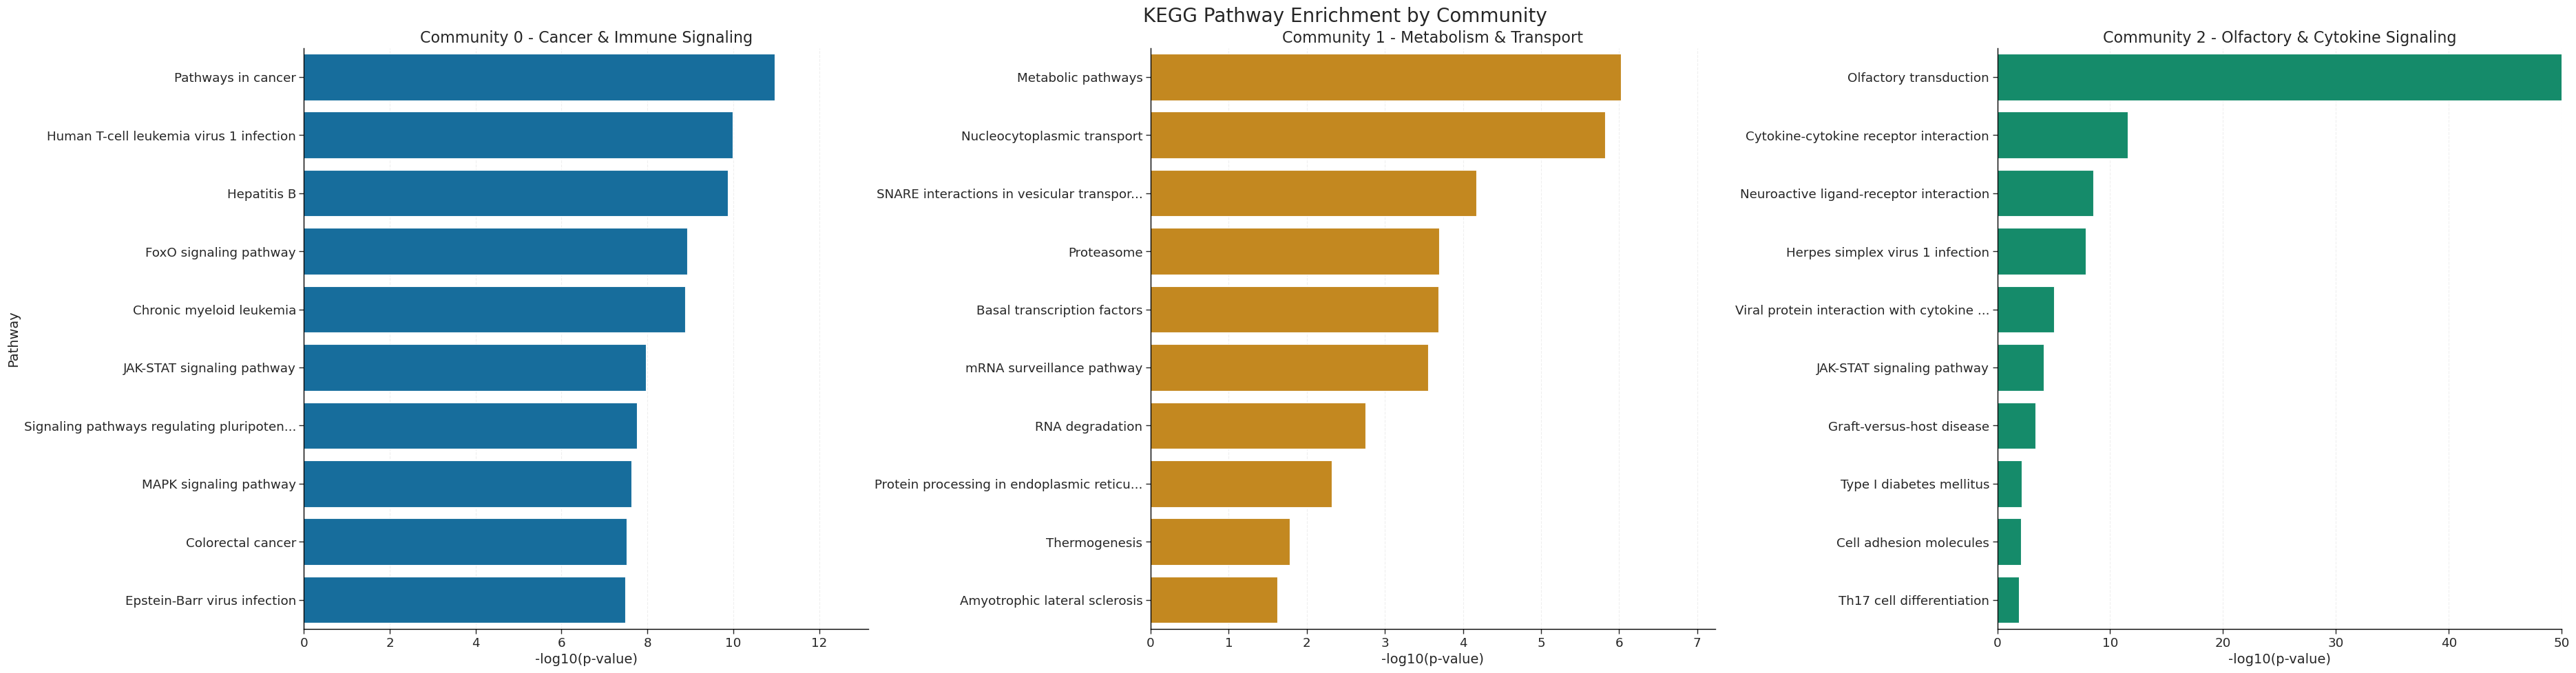

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib as mpl

# Style settings
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0
plt.rcParams['xtick.direction'] = 'out'
plt.rcParams['ytick.direction'] = 'out'

# Theme and context
sns.set_style("ticks")
sns.set_context("paper", font_scale=1.5)

# Color palette
palette = sns.color_palette("colorblind")

# Get data from kegg_results in memory
comm0_data = kegg_results[0]
comm1_data = kegg_results[1]
comm2_data = kegg_results[2]

# Filter KEGG pathways only (already KEGG-only but keeping for consistency)
comm0_kegg = comm0_data[comm0_data['source'] == 'KEGG'].sort_values('p_value').head(10)
comm1_kegg = comm1_data[comm1_data['source'] == 'KEGG'].sort_values('p_value').head(10)
comm2_kegg = comm2_data[comm2_data['source'] == 'KEGG'].sort_values('p_value').head(10)

# Function to shorten pathway names
def shorten_name(name, max_length=40):
    if len(name) > max_length:
        return name[:max_length] + "..."
    return name

# Handle p-values of 0
def safe_log10(x):
    if x <= 0:
        return 300  # Set a large value
    return -np.log10(x)

# Data and plot settings for each community
community_data = [
    (comm0_kegg, 'Community 0 - Cancer & Immune Signaling', palette[0]),
    (comm1_kegg, 'Community 1 - Metabolism & Transport', palette[1]),
    (comm2_kegg, 'Community 2 - Olfactory & Cytokine Signaling', palette[2])
]

# Create a figure with subplots horizontally
fig, axes = plt.subplots(1, 3, figsize=(36, 10))

# Create graphs for each community
for i, (data, title, color) in enumerate(community_data):
    ax = axes[i]

    # Prepare data
    data = data.sort_values('p_value').head(10)
    data['short_name'] = data['name'].apply(lambda x: shorten_name(x, 40))
    data['-log10(p)'] = data['p_value'].apply(safe_log10)

    # Bar plot
    barplot = sns.barplot(x='-log10(p)', y='short_name', data=data, color=color, ax=ax)

    # Axis labels and title
    ax.set_xlabel('-log10(p-value)', fontsize=14)
    if i == 0:  # Only set ylabel for the first subplot
        ax.set_ylabel('Pathway', fontsize=14)
    else:
        ax.set_ylabel('')

    ax.set_title(title, fontsize=16)

    # Border settings
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    for spine_name, spine in ax.spines.items():
        if spine_name in ['left', 'bottom']:
            spine.set_edgecolor('black')
            spine.set_linewidth(1)

    # Grid settings
    ax.grid(axis='x', linestyle='--', alpha=0.3)

    # Set x-axis range
    max_val = data['-log10(p)'].max()
    if np.isfinite(max_val):
        ax.set_xlim(0, min(max_val * 1.2, 50))
    else:
        ax.set_xlim(0, 50)

# Add a super title
plt.suptitle('KEGG Pathway Enrichment by Community', fontsize=20, y=0.98)

# Adjust layout with more space on the left
plt.tight_layout()
plt.subplots_adjust(top=0.92, wspace=0.5, left=0.08)

# Uncomment the following lines to save the figure if needed
# plt.savefig("combined_communities_kegg_horizontal.svg", format='svg', bbox_inches='tight', dpi=300)
# plt.savefig("combined_communities_kegg_horizontal.png", format='png', bbox_inches='tight', dpi=300)

plt.show()

## 6. Generating Files for Cytoscape

Generate CSV files for visualizing the network analyzed with NetworkX in Cytoscape.

In [63]:
# To visualize in Cytoscape, uncomment the following code to generate CSV files
# Load the generated files into Cytoscape to visualize the network

# Create node data (including community information)
# node_data = pd.DataFrame.from_dict(dict(G.nodes(data=True)), orient='index')
# node_data.to_csv('nodes_with_communities.csv')
# print("Saved node data: nodes_with_communities.csv")

# Create edge data
# edge_list = []
# for u, v, d in G.edges(data=True):
#     edge_list.append({
#         'Source': u,
#         'Target': v,
#         'Weight': d.get('calibrated_score', 0)
#     })
# edge_data = pd.DataFrame(edge_list)
# edge_data.to_csv('edges_with_scores.csv', index=False)
# print("Saved edge data: edges_with_scores.csv")

print("To visualize in Cytoscape, uncomment the code above to generate CSV files")
print("Node data: accessible via G.nodes(data=True)")
print("Edge data: accessible via G.edges(data=True)")

To visualize in Cytoscape, uncomment the code above to generate CSV files
Node data: accessible via G.nodes(data=True)
Edge data: accessible via G.edges(data=True)


### Extracting Networks Related to Specific Proteins

Extract networks related to specific proteins (E3 ligases or substrates) and create Cytoscape files.

In [64]:
# To visualize networks related to specific proteins in Cytoscape,
# uncomment the following code to generate CSV files

# List of specified proteins (example)
# specified_proteins = [
#     'O14965',  # AURKA
#     'Q12834',  # CDC20
#     'Q9NZJ0',  # DTL
#     'Q9NXI6',  # RNF186
#     'O14543',  # SOCS3
#     'Q96Q27'   # ASB2
# ]

# # Extract edges related to specified proteins from original dataframe
# specified_edges_df = df[(df['e3_uniprot_id'].isin(specified_proteins)) |
#                         (df['substrate_uniprot_id'].isin(specified_proteins))]

# # Filter by threshold
# filtered_edges_df = specified_edges_df[specified_edges_df['calibrated_score'] >= threshold]

# # Create edge list for Cytoscape
# cytoscape_df = filtered_edges_df[['e3_uniprot_id', 'substrate_uniprot_id', 'calibrated_score']]
# cytoscape_df.columns = ['Source', 'Target', 'Weight']

# # Save to file
# output_file = 'specified_proteins_network_cytoscape.csv'
# cytoscape_df.to_csv(output_file, index=False)

# print(f"Created network file for specified proteins: {output_file}")
# print(f"Number of extracted edges: {len(cytoscape_df)}")
# print(f"Included proteins: {', '.join(specified_proteins)}")
# print("\nSample of extracted edges (first 10):")
# print(cytoscape_df.head(10))

print("To visualize specific protein networks in Cytoscape, uncomment the code above")

To visualize specific protein networks in Cytoscape, uncomment the code above


In [ ]:
# To create individual CSV files for each protein, uncomment the following code
# Load these files into Cytoscape to visualize individual protein networks

# for protein in specified_proteins:
#     # Extract edges containing the specified protein as E3 ligase or substrate
#     protein_edges_df = df[(df['e3_uniprot_id'] == protein) |
#                           (df['substrate_uniprot_id'] == protein)]
#
#     # Filter by threshold
#     filtered_protein_edges = protein_edges_df[protein_edges_df['calibrated_score'] >= threshold]
#
#     # Create edge list for Cytoscape
#     cytoscape_protein_df = filtered_protein_edges[['e3_uniprot_id', 'substrate_uniprot_id', 'calibrated_score']]
#     cytoscape_protein_df.columns = ['Source', 'Target', 'Weight']
#
#     # Create filename including protein ID
#     protein_output_file = f'protein_{protein}_network_cytoscape.csv'
#
#     # Save to file
#     cytoscape_protein_df.to_csv(protein_output_file, index=False)
#
#     print(f"Created network file for {protein}: {protein_output_file}")
#     print(f"  Number of extracted edges: {len(cytoscape_protein_df)}")

print("To create individual protein network files, uncomment the code above")

To create individual protein network files, uncomment the code above
